Evaluating all 6 Group Models for Final Comparison...



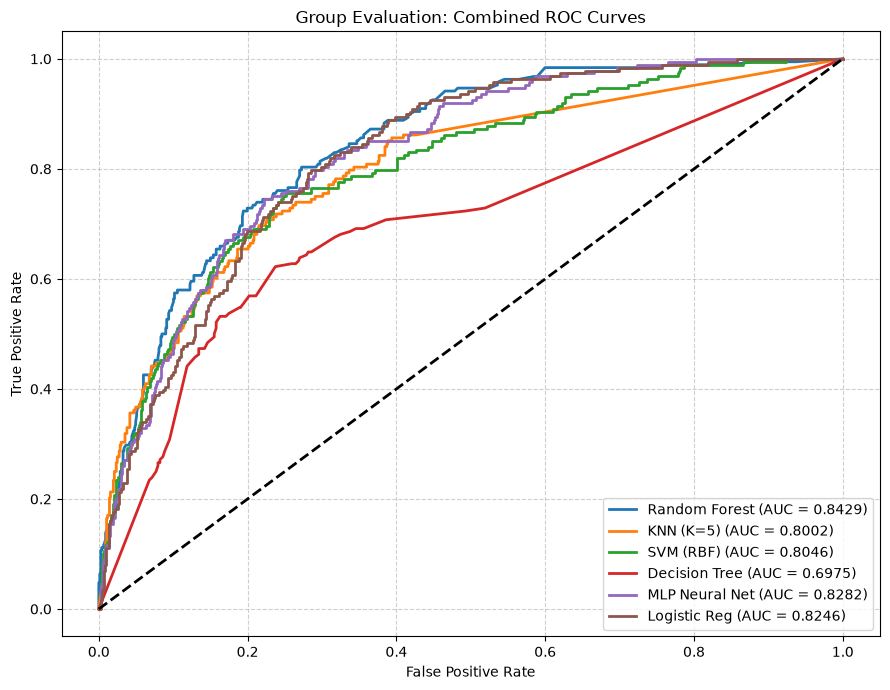

FINAL GROUP COMPARISON TABLE
    Model Name  Accuracy (%)  Precision  Recall  Weighted F1  ROC AUC
 Random Forest         83.14     0.6154  0.3830       0.8155   0.8429
MLP Neural Net         82.09     0.5639  0.3989       0.8087   0.8282
  Logistic Reg         81.88     0.5664  0.3404       0.8005   0.8246
     SVM (RBF)         82.62     0.6122  0.3191       0.8036   0.8046
     KNN (K=5)         81.99     0.5519  0.4521       0.8129   0.8002
 Decision Tree         78.12     0.4483  0.4840       0.7843   0.6975


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, auc)

# 1. Load Data & Define Binary Target (quality >= 7)
df = pd.read_csv('processed_wine_quality.csv')
df['quality_binary'] = (df['quality'] >= 7).astype(int)

# Use the 12 standardized features (excluding redundant PC1, PC2, and TotalAcidity)
features_full = [
    'fixed acidity_scaled', 'volatile acidity_scaled', 'citric acid_scaled', 
    'residual sugar_scaled', 'chlorides_scaled', 'free sulfur dioxide_scaled', 
    'total sulfur dioxide_scaled', 'density_scaled', 'pH_scaled', 
    'sulphates_scaled', 'alcohol_scaled', 'wine_type_encoded'
]

X = df[features_full]
y = df['quality_binary']

# 2. Stratified Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 3. 6 Models Setup (Configured with Tuned Hyperparameters)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    "KNN (K=5)": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "SVM (RBF)": SVC(C=10, kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "MLP Neural Net": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "Logistic Reg": LogisticRegression(C=10, max_iter=1000, random_state=42)
}

results = []
plt.figure(figsize=(9, 7))

print("Evaluating all 6 Group Models for Final Comparison...\n")

# 4. Train, Predict, and Generate Multi-Model ROC Curves
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Compute and plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
    
    results.append({
        'Model Name': name,
        'Accuracy (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, y_pred, zero_division=0), 4),
        'Weighted F1': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'ROC AUC': round(roc_auc, 4)
    })

# 5. Combined ROC Curve Plot Settings
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.title('Group Evaluation: Combined ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('group_combined_roc.png')
plt.show()

# 6. Final Comparison Table
results_df = pd.DataFrame(results).sort_values('ROC AUC', ascending=False)
print("=" * 85)
print("FINAL GROUP COMPARISON TABLE")
print("=" * 85)
print(results_df.to_string(index=False))
print("=" * 85)